In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

RS = 0.001
RCT = 0.01
CDL = 500
dt = 0.01  

tau = RCT * CDL
print(f"Time constant is {tau} seconds")
print(f"dt = {dt} seconds")
print(f"dt/tau ratio = {dt/tau:.4f}")

Time constant is 5.0 seconds
dt = 0.001 seconds
dt/tau ratio = 0.0002


In [2]:
def model_exact(RS, RCT, CDL, I_signal, dt):
    n = len(I_signal)
    I_1 = np.full(n, np.nan)
    V = np.full(n, np.nan)
    alpha = np.exp(-dt / (RCT * CDL))
    I_1[0] = 0
    V[0] = np.nan
    for k in range(1, n):
        I_1[k] = alpha * I_1[k-1] + (1 - alpha) * I_signal[k]
        V[k] = I_1[k] * RCT + I_signal[k] * RS
    return V, I_1

def model_rk4(RS, RCT, CDL, I_signal, dt):
    n = len(I_signal)
    V_c = np.full(n, np.nan)
    V = np.full(n, np.nan)
    V_c[0] = 0
    V[0] = np.nan
    def dVc(Vc, I):
        return (I - Vc / RCT) / CDL
    for k in range(1, n):
        k1 = dVc(V_c[k-1], I_signal[k-1])
        k2 = dVc(V_c[k-1] + dt/2 * k1, I_signal[k-1])
        k3 = dVc(V_c[k-1] + dt/2 * k2, I_signal[k-1])
        k4 = dVc(V_c[k-1] + dt * k3, I_signal[k-1])
        V_c[k] = V_c[k-1] + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        V[k] = V_c[k] + I_signal[k] * RS
    return V, V_c

def model_euler(RS, RCT, CDL, I_signal, dt):
    n = len(I_signal)
    V_c = np.full(n, np.nan)
    V = np.full(n, np.nan)
    V_c[0] = 0
    V[0] = np.nan
    for k in range(1, n):
        dVc = (I_signal[k-1] - V_c[k-1] / RCT) / CDL
        V_c[k] = V_c[k-1] + dt * dVc
        V[k] = V_c[k] + I_signal[k] * RS
    return V, V_c

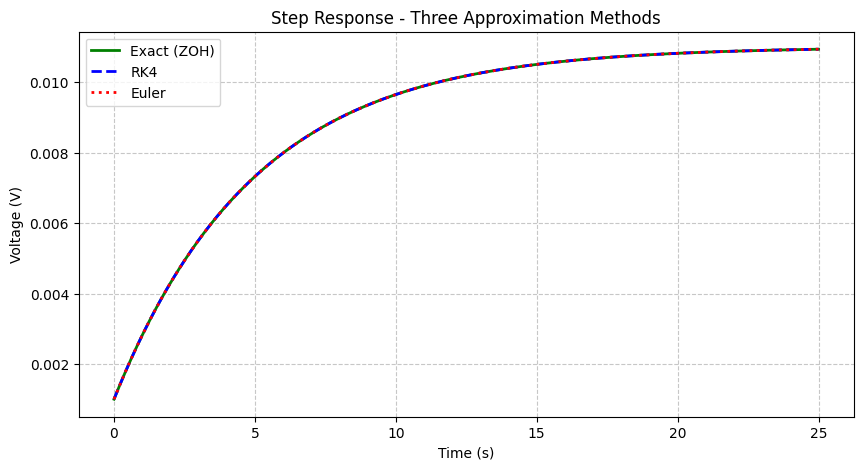

In [3]:
t_step = np.arange(0, 5 * tau, dt)
I_step = np.ones(len(t_step))

V_exact, _ = model_exact(RS, RCT, CDL, I_step, dt)
V_rk4, _ = model_rk4(RS, RCT, CDL, I_step, dt)
V_euler, _ = model_euler(RS, RCT, CDL, I_step, dt)

plt.figure(figsize=(10, 5))
plt.plot(t_step, V_exact, 'g-', linewidth=2, label='Exact (ZOH)')
plt.plot(t_step, V_rk4, 'b--', linewidth=2, label='RK4')
plt.plot(t_step, V_euler, 'r:', linewidth=2, label='Euler')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Step Response - Three Approximation Methods')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
# 1. Simple, clean frequency generation
freqs = np.logspace(-1, 3, 50)

Z_real_exact, Z_imag_exact = [], []
Z_real_rk4, Z_imag_rk4 = [], []
Z_real_euler, Z_imag_euler = [], []

for f in freqs:
    # 2. How much time do we need?
    t_warmup = 5 * tau        # Time to charge the capacitor
    t_signal = 10 / f         # Time for exactly 10 AC cycles
    
    # 3. How many data points is that? (Using your global dt)
    n_warmup = int(t_warmup / dt)
    n_signal = int(t_signal / dt)
    
    # 4. Build ONE simple time array
    n_total = n_warmup + n_signal
    t_full = np.arange(n_total) * dt
    
    # 5. Generate the sine wave
    omega = 2 * np.pi * f
    I_full = np.sin(omega * t_full) + 0.5 * np.sin(3 * omega * t_full)
    
    def extract_Z(V_sweep, I_sweep, f):
        # Slice off the warmup points, keep the rest
        V_clean = V_sweep[n_warmup:]
        I_clean = I_sweep[n_warmup:]
        
        N = len(V_clean)
        V_fft = np.fft.fft(V_clean)
        I_fft = np.fft.fft(I_clean)
        
        # Use your global dt for the FFT!
        freqs_fft = np.fft.fftfreq(N, dt) 
        idx = np.argmin(np.abs(freqs_fft - f))
        Z = V_fft[idx] / I_fft[idx]
        return Z.real, -Z.imag

    # Run the models using your global dt
    V_e, _ = model_exact(RS, RCT, CDL, I_full, dt)
    zr, zi = extract_Z(V_e, I_full, f)
    Z_real_exact.append(zr)
    Z_imag_exact.append(zi)

    V_r, _ = model_rk4(RS, RCT, CDL, I_full, dt)
    zr, zi = extract_Z(V_r, I_full, f)
    Z_real_rk4.append(zr)
    Z_imag_rk4.append(zi)

    V_eu, _ = model_euler(RS, RCT, CDL, I_full, dt)
    zr, zi = extract_Z(V_eu, I_full, f)
    Z_real_euler.append(zr)
    Z_imag_euler.append(zi)

In [5]:
def freq_domain_model(freqs, RS, RCT, CDL):
    omega = 2 * np.pi * freqs
    Z_cdl = 1 / (1j * omega * CDL)
    Z_parallel = (RCT * Z_cdl) / (RCT + Z_cdl)
    return RS + Z_parallel

Z_freq = freq_domain_model(freqs, RS, RCT, CDL)

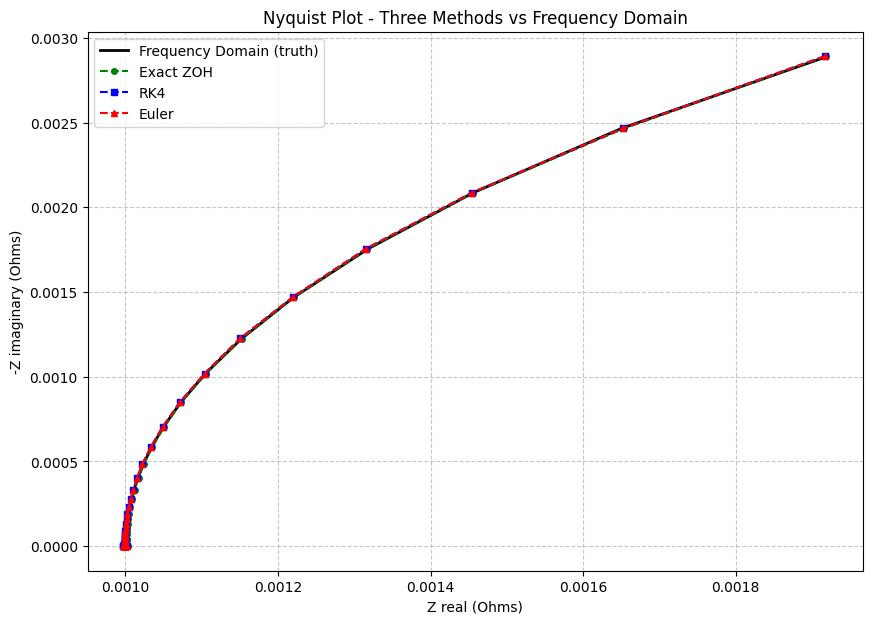

In [6]:
plt.figure(figsize=(10, 7))
plt.plot(Z_freq.real, -Z_freq.imag, 'k-', linewidth=2, label='Frequency Domain (truth)')
plt.plot(Z_real_exact, Z_imag_exact, 'g--o', markersize=4, label='Exact ZOH')
plt.plot(Z_real_rk4, Z_imag_rk4, 'b--s', markersize=4, label='RK4')
plt.plot(Z_real_euler, Z_imag_euler, 'r--^', markersize=4, label='Euler')
plt.xlabel('Z real (Ohms)')
plt.ylabel('-Z imaginary (Ohms)')
plt.title('Nyquist Plot - Three Methods vs Frequency Domain')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

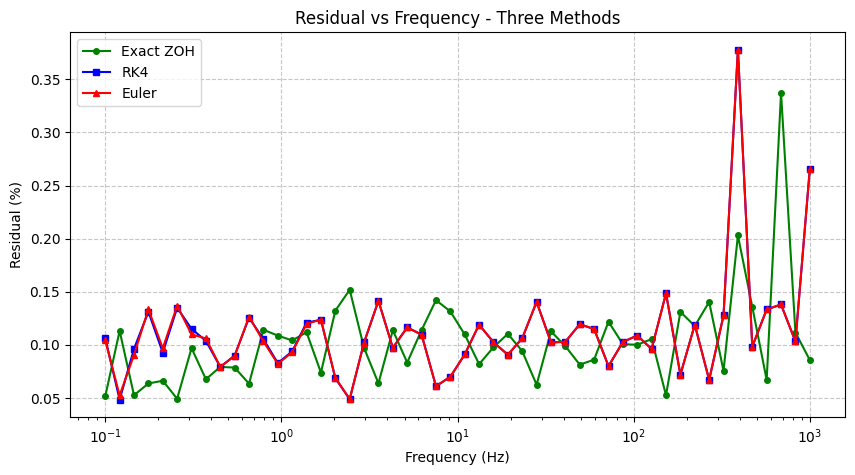

In [7]:
Z_exact_arr = np.array(Z_real_exact) - 1j * np.array(Z_imag_exact)
Z_rk4_arr = np.array(Z_real_rk4) - 1j * np.array(Z_imag_rk4)
Z_euler_arr = np.array(Z_real_euler) - 1j * np.array(Z_imag_euler)

def residual_pct(Z_sim, Z_ref):
    return np.abs(Z_sim - Z_ref) / np.abs(Z_ref) * 100

plt.figure(figsize=(10, 5))
plt.semilogx(freqs, residual_pct(Z_exact_arr, Z_freq), 'g-o', markersize=4, label='Exact ZOH')
plt.semilogx(freqs, residual_pct(Z_rk4_arr, Z_freq), 'b-s', markersize=4, label='RK4')
plt.semilogx(freqs, residual_pct(Z_euler_arr, Z_freq), 'r-^', markersize=4, label='Euler')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Residual (%)')
plt.title('Residual vs Frequency - Three Methods')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

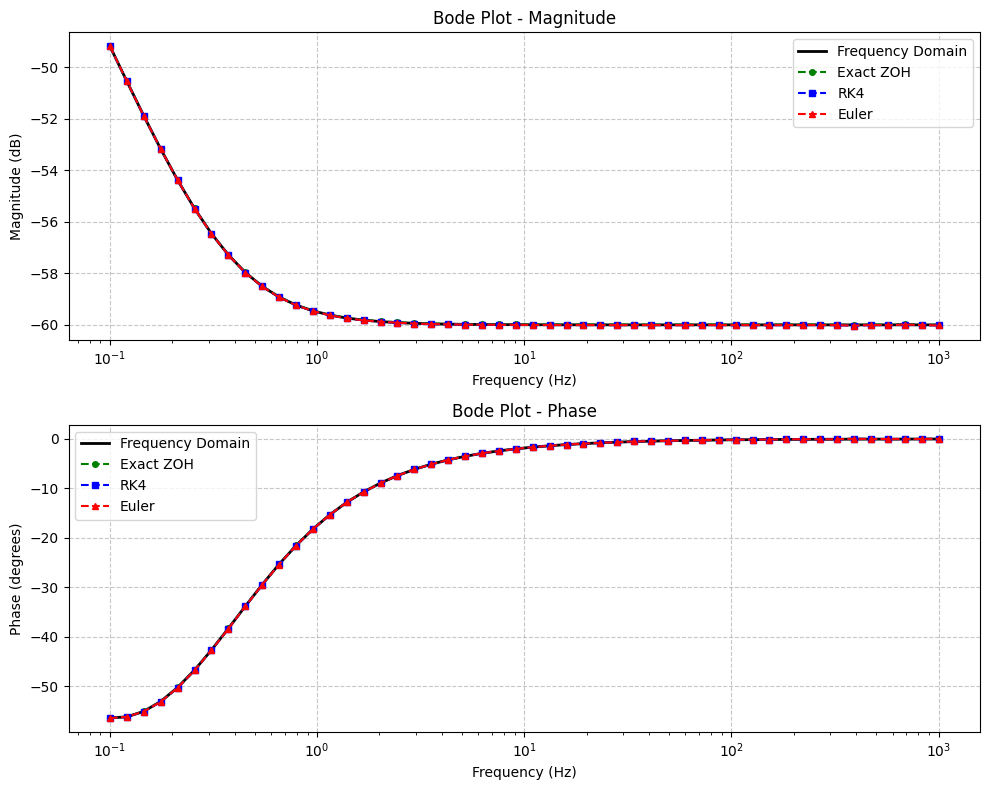

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.semilogx(freqs, 20*np.log10(np.abs(Z_freq)), 'k-', linewidth=2, label='Frequency Domain')
ax1.semilogx(freqs, 20*np.log10(np.abs(Z_exact_arr)), 'g--o', markersize=4, label='Exact ZOH')
ax1.semilogx(freqs, 20*np.log10(np.abs(Z_rk4_arr)), 'b--s', markersize=4, label='RK4')
ax1.semilogx(freqs, 20*np.log10(np.abs(Z_euler_arr)), 'r--^', markersize=4, label='Euler')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('Bode Plot - Magnitude')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

ax2.semilogx(freqs, np.angle(Z_freq, deg=True), 'k-', linewidth=2, label='Frequency Domain')
ax2.semilogx(freqs, np.angle(Z_exact_arr, deg=True), 'g--o', markersize=4, label='Exact ZOH')
ax2.semilogx(freqs, np.angle(Z_rk4_arr, deg=True), 'b--s', markersize=4, label='RK4')
ax2.semilogx(freqs, np.angle(Z_euler_arr, deg=True), 'r--^', markersize=4, label='Euler')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Phase (degrees)')
ax2.set_title('Bode Plot - Phase')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()